# DL Experiments: NER для резюме

## Структура ноутбука

1. **Данные и EDA** — загрузка датасета, распределение сущностей, визуализации
2. **Baseline (SpaCy blank)** — обучение и оценка базовой модели
3. **Улучшенные ML-подходы** — pretrained vectors, Entity Ruler, аугментация данных
4. **DL-подход: SpaCy Transformer** — roberta-base через spacy-transformers
5. **LLM-эксперименты** — zero-shot NER с Qwen3 (0.6B, 1.7B, 4B): влияние размера модели
6. **Итоговое сравнение и выводы** — ML vs DL vs LLM, визуализации, рекомендации

---
## 1. Данные и EDA

In [7]:
!pip install spacy scikit-learn pandas numpy matplotlib seaborn transformers torch accelerate spacy-lookups-data --quiet
!python -m spacy download en_core_web_lg --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')


In [8]:
import json
import re
import math
import random
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

import sys
sys.path.insert(0, str(Path.cwd().parent))

from data_utils import (
    full_clean_pipeline, train_test_split, build_augmented_dataset,
    filter_overlapping_entities, get_entity_ruler_patterns, dataset_stats,
    convert_dataturks_to_spacy, trim_entity_spans, remove_unknown_label,
    validate_entities, filter_empty_resumes
)

DATASET_PATH = Path.cwd().parent / 'datasets' / 'dataturks' / 'Entity Recognition in Resumes.json'
RANDOM_STATE = 42
TEST_SIZE = 0.1

print(f'Dataset: {DATASET_PATH}')
print(f'Exists: {DATASET_PATH.exists()}')

Dataset: /Users/younggolubev/resume_ner/datasets/dataturks/Entity Recognition in Resumes.json
Exists: True


In [9]:
# Загрузка сырых данных для EDA
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    raw_data = [json.loads(line) for line in f]

print(f'Всего резюме в датасете: {len(raw_data)}')
print(f'Пример ключей: {list(raw_data[0].keys())}')
print(f'Длина первого резюме: {len(raw_data[0]["content"])} символов')

Всего резюме в датасете: 220
Пример ключей: ['content', 'annotation', 'extras']
Длина первого резюме: 1622 символов


In [10]:
# Извлекаем все сущности из сырых данных
all_entities = []
entities_per_resume = []

for resume in raw_data:
    annotations = resume.get('annotation', [])
    if annotations is None:
        annotations = []
    count = 0
    for ann in annotations:
        labels = ann.get('label', [])
        if not labels:
            continue
        label = labels[0] if isinstance(labels, list) else labels
        text = ann['points'][0]['text']
        all_entities.append({'label': label, 'text': text, 'length': len(text)})
        count += 1
    entities_per_resume.append(count)

entities_df = pd.DataFrame(all_entities)
print(f'Всего аннотированных сущностей: {len(entities_df)}')
print(f'Уникальных типов: {entities_df["label"].nunique()}')
print(f'Среднее сущностей на резюме: {np.mean(entities_per_resume):.1f}')
print(f'Медиана: {np.median(entities_per_resume):.0f}')

Всего аннотированных сущностей: 3556
Уникальных типов: 11
Среднее сущностей на резюме: 16.2
Медиана: 13


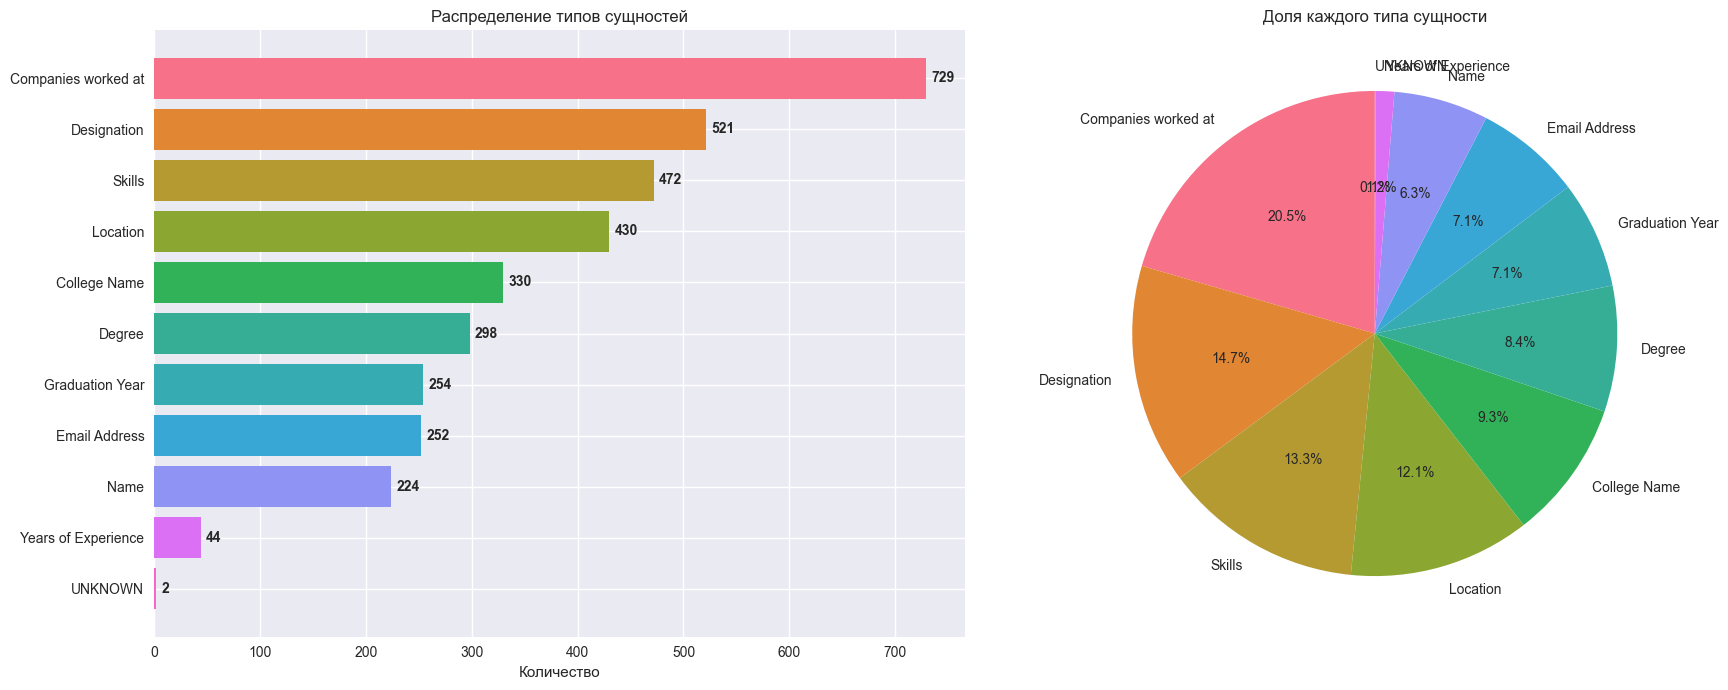

In [11]:
# Распределение типов сущностей
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

label_counts = entities_df['label'].value_counts()
colors = sns.color_palette('husl', len(label_counts))

# Bar chart
bars = axes[0].barh(range(len(label_counts)), label_counts.values, color=colors)
axes[0].set_yticks(range(len(label_counts)))
axes[0].set_yticklabels(label_counts.index)
axes[0].set_xlabel('Количество')
axes[0].set_title('Распределение типов сущностей')
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Доля каждого типа сущности')

plt.tight_layout()
plt.show()

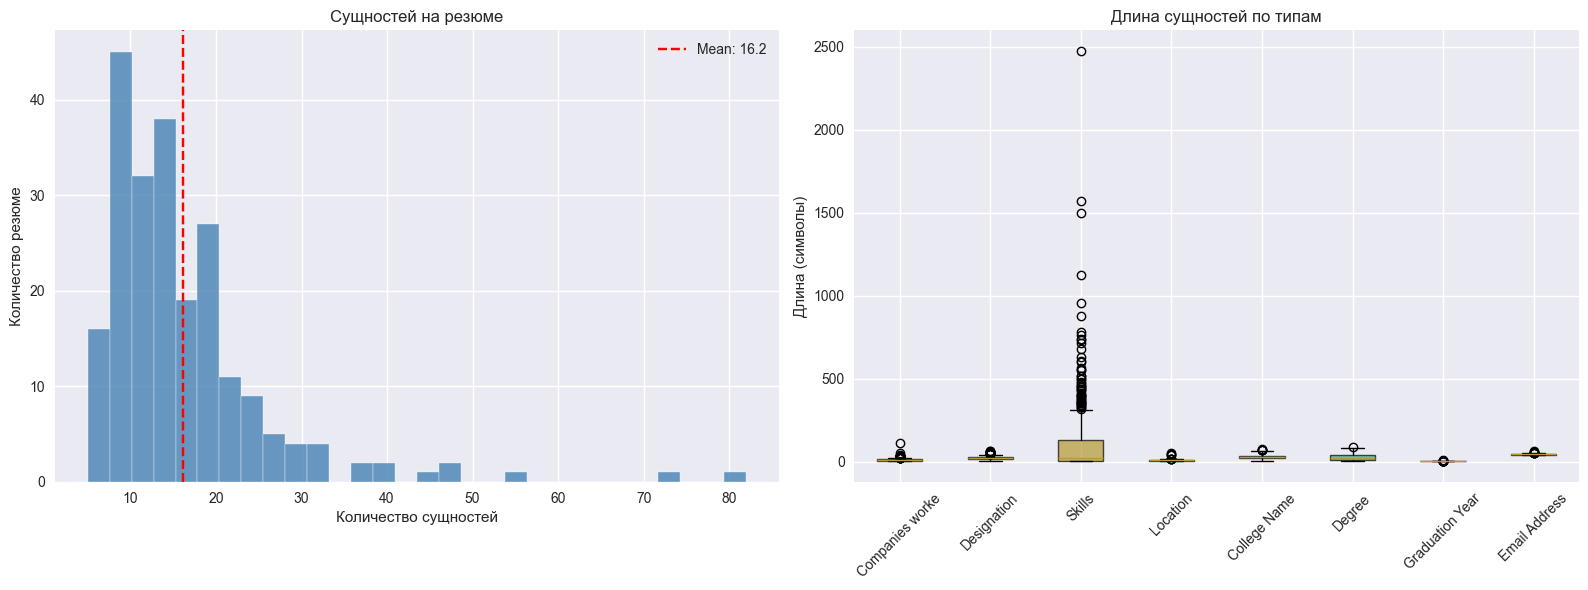

In [12]:
# Распределение количества сущностей на резюме + длины сущностей
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(entities_per_resume, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(entities_per_resume), color='red', linestyle='--',
                label=f'Mean: {np.mean(entities_per_resume):.1f}')
axes[0].set_xlabel('Количество сущностей')
axes[0].set_ylabel('Количество резюме')
axes[0].set_title('Сущностей на резюме')
axes[0].legend()

top_labels = label_counts.head(8).index.tolist()
length_data = [entities_df[entities_df['label'] == l]['length'].values for l in top_labels]
bp = axes[1].boxplot(length_data, labels=[l[:15] for l in top_labels], patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:8]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Длина (символы)')
axes[1].set_title('Длина сущностей по типам')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# Топ значений для ключевых типов сущностей
for entity_type in ['Skills', 'Companies worked at', 'Designation', 'Location']:
    subset = entities_df[entities_df['label'] == entity_type]['text']
    counter = Counter(subset)
    print(f'\n=== {entity_type} (уникальных: {len(counter)}) ===')
    for val, cnt in counter.most_common(10):
        print(f'  {val[:60]:60s} x{cnt}')


=== Skills (уникальных: 348) ===
  Linux                                                        x10
  SAP                                                          x10
  Java                                                         x9
  HTML                                                         x8
  CSS                                                          x7
  CHEF                                                         x7
  AWS                                                          x7
  Docker                                                       x6
  DOJO                                                         x5
  Velocity                                                     x5

=== Companies worked at (уникальных: 144) ===
  Microsoft                                                    x121
  Oracle                                                       x111
  Cisco                                                        x49
  Infosys Limited                                     

---
## 2. Подготовка данных

Применяем полный pipeline очистки:
- Исправление entity offsets (используем оригинальные аннотации вместо regex first-match)
- Trim whitespace из entity spans
- Удаление мусорного класса UNKNOWN
- Валидация spans
- Обработка overlapping entities (стратегия keep_longer)
- Фильтрация пустых резюме

In [14]:
data = full_clean_pipeline(DATASET_PATH)

train_data, test_data = train_test_split(data, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_data, dev_data = train_test_split(train_data, test_size=0.1, random_state=RANDOM_STATE + 1)

print(f'Train: {len(train_data)} | Dev: {len(dev_data)} | Test: {len(test_data)}')

# Аугментированная версия
train_aug = build_augmented_dataset(train_data, random_state=RANDOM_STATE)
train_aug = filter_overlapping_entities(train_aug, strategy='keep_longer')

dataset_stats(test_data, 'Test set')

Loading and cleaning data...
  [clean] Removed 2 UNKNOWN entities
  [clean] 213 overlapping entities found, 0 resolved by keeping longer span
  Final: 220 resumes

Train: 179 | Dev: 19 | Test: 22
Augmenting training data...
  Original: 179, After augmentation: 716 (4.0x)

--- Test set ---
  Resumes: 22, Entities: 312
    Companies worked at: 72
    Designation: 48
    College Name: 36
    Location: 34
    Degree: 28
    Skills: 28
    Name: 23
    Graduation Year: 22
    Email Address: 17
    Years of Experience: 4



{'n_resumes': 22,
 'n_entities': 312,
 'label_counts': {'Name': 23,
  'Location': 34,
  'Email Address': 17,
  'Designation': 48,
  'Companies worked at': 72,
  'Degree': 28,
  'College Name': 36,
  'Skills': 28,
  'Years of Experience': 4,
  'Graduation Year': 22}}

---
## 3. Baseline: SpaCy blank model

Базовая модель — `spacy.blank("en")` с архитектурой HashEmbedCNN.
Это модель без предобученных эмбеддингов, которая учится с нуля на наших данных.

In [19]:
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def calculate_entity_metrics(nlp_model, test_data):
    """Entity-level strict-match metrics (overall + per-type)."""
    tp, fp, fn = 0, 0, 0
    per_type = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for text, ann in test_data:
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}
        pred_doc = nlp_model(text)
        pred_set = {(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents}

        matched = true_set & pred_set
        tp += len(matched)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

        for s, e, l in matched:
            per_type[l]['tp'] += 1
        for s, e, l in pred_set - true_set:
            per_type[l]['fp'] += 1
        for s, e, l in true_set - pred_set:
            per_type[l]['fn'] += 1

    def _prf(tp_, fp_, fn_):
        p = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
        r = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
        f = 2 * p * r / (p + r) if (p + r) else 0
        return p, r, f

    overall_p, overall_r, overall_f1 = _prf(tp, fp, fn)

    per_type_metrics = {}
    for label in sorted(per_type):
        d = per_type[label]
        p, r, f = _prf(d['tp'], d['fp'], d['fn'])
        per_type_metrics[label] = {'precision': p, 'recall': r, 'f1': f, 'support': d['tp'] + d['fn']}

    return {'precision': overall_p, 'recall': overall_r, 'f1': overall_f1,
            'tp': tp, 'fp': fp, 'fn': fn, 'per_type': per_type_metrics}


def calculate_token_metrics(nlp_model, test_data):
    """Token-level NER metrics."""
    all_true, all_pred = [], []
    for text, ann in test_data:
        doc = nlp_model.make_doc(text)
        true_labels = ['O'] * len(doc)
        for start, end, label in ann.get('entities', []):
            for t in doc:
                if t.idx >= start and t.idx + len(t.text) <= end:
                    true_labels[t.i] = label
        pred_doc = nlp_model(text)
        pred_labels = [t.ent_type_ if t.ent_type_ else 'O' for t in pred_doc]
        n = min(len(true_labels), len(pred_labels))
        all_true.extend(true_labels[:n])
        all_pred.extend(pred_labels[:n])
    acc = accuracy_score(all_true, all_pred)
    p, r, f1, _ = precision_recall_fscore_support(all_true, all_pred, average='weighted', zero_division=0)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}


def train_spacy(nlp_model, train_data, dev_data, n_epochs=30, dropout=0.3, patience=5, label='model'):
    """Train SpaCy NER with minibatch and early stopping."""
    ner = nlp_model.get_pipe('ner')
    for _, ann in train_data:
        for _, _, lbl in ann.get('entities', []):
            ner.add_label(lbl)

    examples = []
    for text, ann in train_data[:10]:
        doc = nlp_model.make_doc(text)
        examples.append(Example.from_dict(doc, ann))

    keep = {'ner', 'entity_ruler', 'transformer'}
    other = [p for p in nlp_model.pipe_names if p not in keep]
    with nlp_model.disable_pipes(*other):
        # resume_training() for models with pretrained tok2vec (avoids lookups init error)
        # initialize() for blank models that need full init
        has_pretrained = 'tok2vec' in nlp_model.pipe_names
        if has_pretrained:
            optimizer = nlp_model.resume_training(get_examples=lambda: examples)
        else:
            optimizer = nlp_model.initialize(get_examples=lambda: examples)

        best_f1, best_weights, no_improve = 0.0, None, 0
        history = []
        start = time.time()

        for epoch in range(1, n_epochs + 1):
            random.shuffle(train_data)
            losses = {}
            for batch in minibatch(train_data, size=compounding(4.0, 32.0, 1.001)):
                exs = [Example.from_dict(nlp_model.make_doc(t), a) for t, a in batch]
                nlp_model.update(exs, drop=dropout, sgd=optimizer, losses=losses)

            dev_m = calculate_entity_metrics(nlp_model, dev_data)
            dev_f1 = dev_m['f1']
            loss = losses.get('ner', 0)
            history.append({'epoch': epoch, 'loss': loss, 'dev_f1': dev_f1})
            print(f'  [{label}] Epoch {epoch:2d}/{n_epochs}  loss={loss:.0f}  dev_F1={dev_f1:.4f}')

            if dev_f1 > best_f1:
                best_f1 = dev_f1
                best_weights = nlp_model.to_bytes()
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f'  Early stopping at epoch {epoch}')
                    break

        elapsed = time.time() - start

    if best_weights:
        nlp_model.from_bytes(best_weights)
    print(f'  Best dev F1: {best_f1:.4f} ({elapsed:.0f}s)\n')
    return nlp_model, history, elapsed

In [20]:
# Обучение baseline
nlp_baseline = spacy.blank('en')
nlp_baseline.add_pipe('ner', last=True)

nlp_baseline, hist_baseline, time_baseline = train_spacy(
    nlp_baseline, train_data, dev_data, n_epochs=30, dropout=0.3, patience=5, label='Baseline')

baseline_ent = calculate_entity_metrics(nlp_baseline, test_data)
baseline_tok = calculate_token_metrics(nlp_baseline, test_data)
print(f'Baseline  Entity-F1={baseline_ent["f1"]:.4f}  Token-Acc={baseline_tok["accuracy"]:.4f}')

  [Baseline] Epoch  1/30  loss=35114  dev_F1=0.0000
  [Baseline] Epoch  2/30  loss=5647  dev_F1=0.0423
  [Baseline] Epoch  3/30  loss=7486  dev_F1=0.2155
  [Baseline] Epoch  4/30  loss=4837  dev_F1=0.3136
  [Baseline] Epoch  5/30  loss=4287  dev_F1=0.4075
  [Baseline] Epoch  6/30  loss=4080  dev_F1=0.4596
  [Baseline] Epoch  7/30  loss=4051  dev_F1=0.3721
  [Baseline] Epoch  8/30  loss=3535  dev_F1=0.5145
  [Baseline] Epoch  9/30  loss=3383  dev_F1=0.4790
  [Baseline] Epoch 10/30  loss=3120  dev_F1=0.5319
  [Baseline] Epoch 11/30  loss=3061  dev_F1=0.4892
  [Baseline] Epoch 12/30  loss=2939  dev_F1=0.5338
  [Baseline] Epoch 13/30  loss=2742  dev_F1=0.5639
  [Baseline] Epoch 14/30  loss=2657  dev_F1=0.4592
  [Baseline] Epoch 15/30  loss=2604  dev_F1=0.5652
  [Baseline] Epoch 16/30  loss=2508  dev_F1=0.5011
  [Baseline] Epoch 17/30  loss=2508  dev_F1=0.5542
  [Baseline] Epoch 18/30  loss=2404  dev_F1=0.4583
  [Baseline] Epoch 19/30  loss=2320  dev_F1=0.5143
  [Baseline] Epoch 20/30  loss

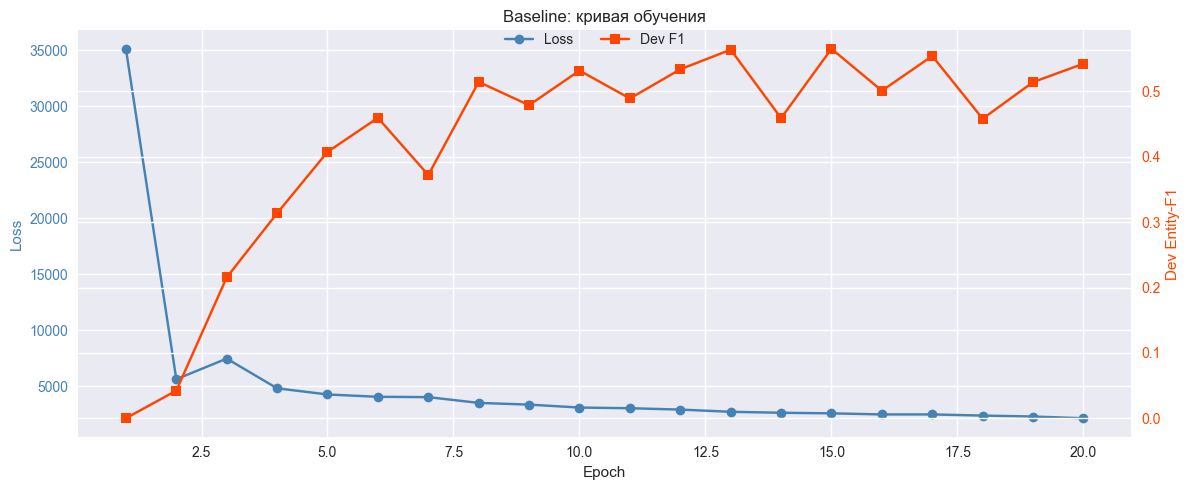

In [21]:
# Кривая обучения baseline
hist_df = pd.DataFrame(hist_baseline)
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.plot(hist_df['epoch'], hist_df['loss'], 'o-', color='steelblue', label='Loss')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Dev Entity-F1', color='orangered')
ax2.plot(hist_df['epoch'], hist_df['dev_f1'], 's-', color='orangered', label='Dev F1')
ax2.tick_params(axis='y', labelcolor='orangered')

plt.title('Baseline: кривая обучения')
fig.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.95))
plt.tight_layout()
plt.show()

---
## 4. Улучшенные ML-подходы

Тестируем три улучшения поверх baseline:

| Модель | Описание |
|---|---|
| **A+aug** | Baseline + аугментация (entity swap, case variation, skill synonyms) |
| **B: Pretrained** | en_core_web_lg (GloVe 300d, 685k vectors) + NER |
| **B+aug** | Pretrained + аугментация |
| **C: Hybrid** | Pretrained + Entity Ruler (regex для Email/Year/Experience) + NER |

In [22]:
# Все результаты будем собирать сюда
all_results = [{
    'name': 'A: Baseline',
    'data': 'clean',
    'entity': baseline_ent,
    'token': baseline_tok,
    'time': time_baseline,
    'history': hist_baseline,
}]


def load_web_lg():
    exclude = ['ner', 'parser', 'lemmatizer', 'attribute_ruler', 'tagger', 'senter', 'sentencizer']
    nlp = spacy.load('en_core_web_lg', exclude=exclude)
    for pipe_name in list(nlp.pipe_names):
        if pipe_name != 'tok2vec':
            nlp.remove_pipe(pipe_name)
    return nlp

In [23]:
# A+aug: Baseline + аугментация
nlp_a_aug = spacy.blank('en')
nlp_a_aug.add_pipe('ner', last=True)
nlp_a_aug, hist_a_aug, time_a_aug = train_spacy(
    nlp_a_aug, train_aug, dev_data, label='A+aug')

a_aug_ent = calculate_entity_metrics(nlp_a_aug, test_data)
a_aug_tok = calculate_token_metrics(nlp_a_aug, test_data)
all_results.append({'name': 'A+aug: Baseline', 'data': 'augmented',
                    'entity': a_aug_ent, 'token': a_aug_tok,
                    'time': time_a_aug, 'history': hist_a_aug})
print(f'A+aug  Entity-F1={a_aug_ent["f1"]:.4f}  Token-Acc={a_aug_tok["accuracy"]:.4f}')

  [A+aug] Epoch  1/30  loss=44119  dev_F1=0.3131
  [A+aug] Epoch  2/30  loss=17251  dev_F1=0.4921
  [A+aug] Epoch  3/30  loss=12904  dev_F1=0.4958
  [A+aug] Epoch  4/30  loss=11421  dev_F1=0.5219
  [A+aug] Epoch  5/30  loss=9914  dev_F1=0.5217
  [A+aug] Epoch  6/30  loss=9006  dev_F1=0.4730
  [A+aug] Epoch  7/30  loss=8229  dev_F1=0.4959
  [A+aug] Epoch  8/30  loss=7745  dev_F1=0.5113
  [A+aug] Epoch  9/30  loss=7371  dev_F1=0.5245
  [A+aug] Epoch 10/30  loss=6778  dev_F1=0.5320
  [A+aug] Epoch 11/30  loss=6609  dev_F1=0.5021
  [A+aug] Epoch 12/30  loss=6009  dev_F1=0.4979
  [A+aug] Epoch 13/30  loss=5542  dev_F1=0.4924
  [A+aug] Epoch 14/30  loss=5432  dev_F1=0.4762
  [A+aug] Epoch 15/30  loss=5112  dev_F1=0.4872
  Early stopping at epoch 15
  Best dev F1: 0.5320 (841s)

A+aug  Entity-F1=0.5464  Token-Acc=0.9013


In [24]:
# B: Pretrained (en_core_web_lg tok2vec)
nlp_b = load_web_lg()
nlp_b.add_pipe('ner', last=True)
nlp_b, hist_b, time_b = train_spacy(nlp_b, train_data, dev_data, label='B: Pretrained')

b_ent = calculate_entity_metrics(nlp_b, test_data)
b_tok = calculate_token_metrics(nlp_b, test_data)
all_results.append({'name': 'B: Pretrained', 'data': 'clean',
                    'entity': b_ent, 'token': b_tok,
                    'time': time_b, 'history': hist_b})
print(f'B: Pretrained  Entity-F1={b_ent["f1"]:.4f}  Token-Acc={b_tok["accuracy"]:.4f}')

  [B: Pretrained] Epoch  1/30  loss=32437  dev_F1=0.0000
  [B: Pretrained] Epoch  2/30  loss=7091  dev_F1=0.1294
  [B: Pretrained] Epoch  3/30  loss=5643  dev_F1=0.2720
  [B: Pretrained] Epoch  4/30  loss=4975  dev_F1=0.3651
  [B: Pretrained] Epoch  5/30  loss=4040  dev_F1=0.4553
  [B: Pretrained] Epoch  6/30  loss=3893  dev_F1=0.4970
  [B: Pretrained] Epoch  7/30  loss=3578  dev_F1=0.5156
  [B: Pretrained] Epoch  8/30  loss=3634  dev_F1=0.5459
  [B: Pretrained] Epoch  9/30  loss=3394  dev_F1=0.5287
  [B: Pretrained] Epoch 10/30  loss=3257  dev_F1=0.5139
  [B: Pretrained] Epoch 11/30  loss=3011  dev_F1=0.5078
  [B: Pretrained] Epoch 12/30  loss=2872  dev_F1=0.5640
  [B: Pretrained] Epoch 13/30  loss=2883  dev_F1=0.5512
  [B: Pretrained] Epoch 14/30  loss=2603  dev_F1=0.5663
  [B: Pretrained] Epoch 15/30  loss=2619  dev_F1=0.5204
  [B: Pretrained] Epoch 16/30  loss=2566  dev_F1=0.5195
  [B: Pretrained] Epoch 17/30  loss=2436  dev_F1=0.5119
  [B: Pretrained] Epoch 18/30  loss=2264  dev_F

In [25]:
# B+aug: Pretrained + аугментация
nlp_b_aug = load_web_lg()
nlp_b_aug.add_pipe('ner', last=True)
nlp_b_aug, hist_b_aug, time_b_aug = train_spacy(nlp_b_aug, train_aug, dev_data, label='B+aug')

b_aug_ent = calculate_entity_metrics(nlp_b_aug, test_data)
b_aug_tok = calculate_token_metrics(nlp_b_aug, test_data)
all_results.append({'name': 'B+aug: Pretrained', 'data': 'augmented',
                    'entity': b_aug_ent, 'token': b_aug_tok,
                    'time': time_b_aug, 'history': hist_b_aug})
print(f'B+aug  Entity-F1={b_aug_ent["f1"]:.4f}  Token-Acc={b_aug_tok["accuracy"]:.4f}')

  [B+aug] Epoch  1/30  loss=51630  dev_F1=0.4190
  [B+aug] Epoch  2/30  loss=16344  dev_F1=0.5618
  [B+aug] Epoch  3/30  loss=13240  dev_F1=0.5386
  [B+aug] Epoch  4/30  loss=11246  dev_F1=0.5327
  [B+aug] Epoch  5/30  loss=10061  dev_F1=0.5321
  [B+aug] Epoch  6/30  loss=8925  dev_F1=0.5313
  [B+aug] Epoch  7/30  loss=8551  dev_F1=0.5550
  Early stopping at epoch 7
  Best dev F1: 0.5618 (535s)

B+aug  Entity-F1=0.5397  Token-Acc=0.7824


In [26]:
# C: Hybrid (pretrained + Entity Ruler)
nlp_c = load_web_lg()
ruler = nlp_c.add_pipe('entity_ruler')
ruler.add_patterns(get_entity_ruler_patterns())
nlp_c.add_pipe('ner', last=True)
nlp_c, hist_c, time_c = train_spacy(nlp_c, train_data, dev_data, label='C: Hybrid')

c_ent = calculate_entity_metrics(nlp_c, test_data)
c_tok = calculate_token_metrics(nlp_c, test_data)
all_results.append({'name': 'C: Hybrid', 'data': 'clean',
                    'entity': c_ent, 'token': c_tok,
                    'time': time_c, 'history': hist_c})
print(f'C: Hybrid  Entity-F1={c_ent["f1"]:.4f}  Token-Acc={c_tok["accuracy"]:.4f}')

/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/pyth

  [C: Hybrid] Epoch  1/30  loss=33569  dev_F1=0.0000


/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/pyth

  [C: Hybrid] Epoch  2/30  loss=6691  dev_F1=0.0447


/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/pyth

...

/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/pyth

  [C: Hybrid] Epoch 17/30  loss=2530  dev_F1=0.5471
  Early stopping at epoch 17
  Best dev F1: 0.5818 (339s)



/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/pyth

C: Hybrid  Entity-F1=0.5619  Token-Acc=0.9132


/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))
/Users/younggolubev/resume_ner/venv/lib/python3.13/site-packages/spacy/pipeline/entityruler.py:366: UserWarning: [W036] The component 'entity_ruler' does not have any patterns defined.
  warnings.warn(Warnings.W036.format(name=self.name))


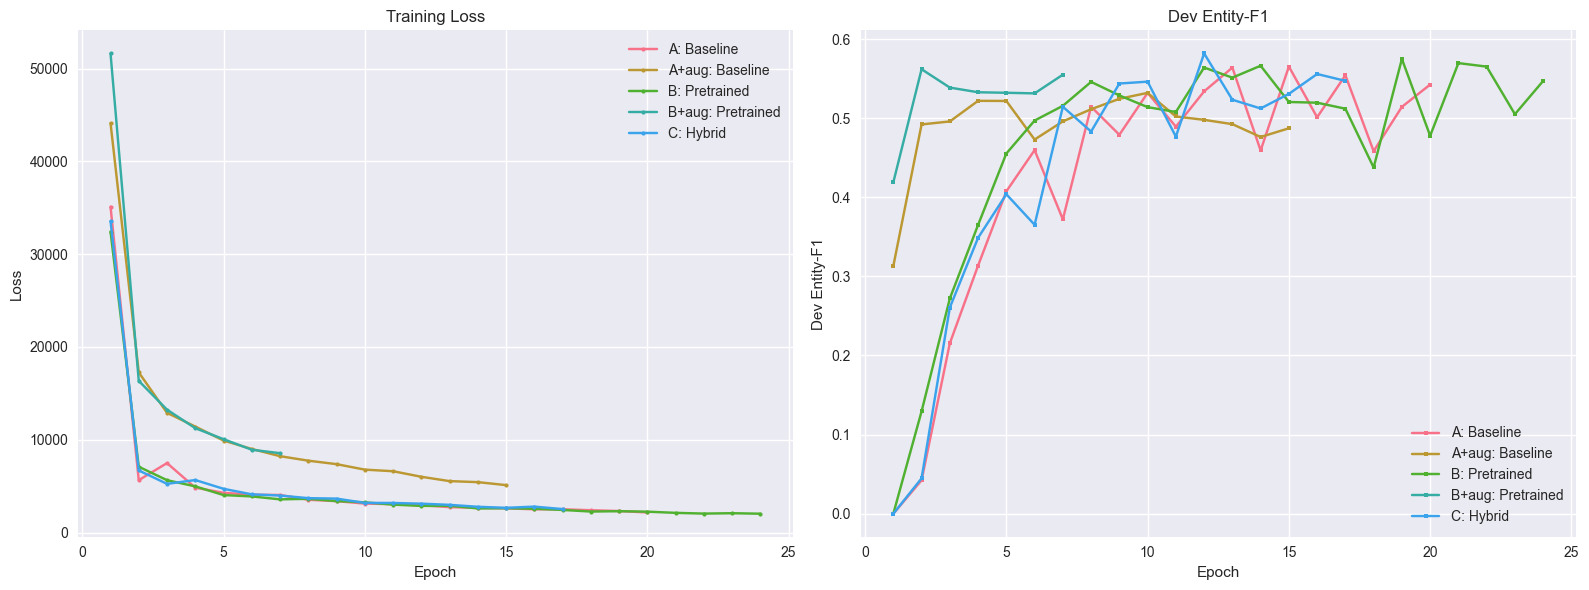

In [27]:
# Визуализация: сравнение кривых обучения всех моделей
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for res in all_results:
    h = pd.DataFrame(res['history'])
    axes[0].plot(h['epoch'], h['loss'], 'o-', markersize=3, label=res['name'])
    axes[1].plot(h['epoch'], h['dev_f1'], 's-', markersize=3, label=res['name'])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dev Entity-F1')
axes[1].set_title('Dev Entity-F1')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. LLM-эксперименты: Qwen3 (0.6B / 1.7B / 4B)

Принципиально другой подход: вместо обучения NER-модели на наших данных, используем
предобученные LLM в **zero-shot** режиме. Модель получает текст резюме и промпт с
описанием нужных сущностей, и должна вернуть их в JSON формате.

Сравниваем три размера Qwen3:
- **Qwen3-0.6B** (0.8B параметров) — самая маленькая
- **Qwen3-1.7B** (2B параметров) — средняя
- **Qwen3-4B** (4B параметров) — самая большая из тестируемых

Все модели запускаются локально на Apple Silicon (MPS).

In [28]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

ENTITY_TYPES = [
    'Name', 'Email Address', 'Location', 'College Name', 'Degree',
    'Graduation Year', 'Companies worked at', 'Designation',
    'Skills', 'Years of Experience',
]

NER_PROMPT_TEMPLATE = """Extract named entities from the following resume text.
Return ONLY a valid JSON object with these entity types as keys: {entity_types}
Each key should map to a list of extracted string values. If no entities found for a type, use an empty list.
Do not include any explanation, only the JSON.

Resume text:
---
{resume_text}
---

JSON:"""

Device: mps
PyTorch: 2.10.0


In [29]:
def load_qwen_model(model_name, device=DEVICE):
    """Load a Qwen3 model and tokenizer."""
    print(f'Loading {model_name}...')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map=device,
    )
    model.eval()
    print(f'  Loaded on {device}, params: {sum(p.numel() for p in model.parameters())/1e9:.1f}B')
    return model, tokenizer


def extract_entities_llm(model, tokenizer, text, max_new_tokens=1024):
    """Run zero-shot NER using an LLM."""
    truncated = text[:3000]
    prompt = NER_PROMPT_TEMPLATE.format(
        entity_types=', '.join(ENTITY_TYPES),
        resume_text=truncated
    )

    messages = [{'role': 'user', 'content': prompt}]
    chat_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
        enable_thinking=False
    )
    inputs = tokenizer(chat_text, return_tensors='pt').to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    generated = outputs[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(generated, skip_special_tokens=True)
    return response


def parse_llm_response(response, text):
    """Parse JSON from LLM response and convert to (start, end, label) spans."""
    # Extract JSON block
    json_str = response.strip()
    if '```json' in json_str:
        json_str = json_str.split('```json')[1].split('```')[0]
    elif '```' in json_str:
        json_str = json_str.split('```')[1].split('```')[0]
    # Try to find JSON object
    brace_start = json_str.find('{')
    brace_end = json_str.rfind('}')
    if brace_start != -1 and brace_end != -1:
        json_str = json_str[brace_start:brace_end + 1]

    try:
        data = json.loads(json_str)
    except json.JSONDecodeError:
        return []

    entities = []
    for label, values in data.items():
        if not isinstance(values, list):
            values = [values]
        for val in values:
            if not isinstance(val, str) or not val.strip():
                continue
            val_clean = val.strip()
            match = re.search(re.escape(val_clean), text)
            if match:
                entities.append((match.start(), match.end(), label))

    return entities


def evaluate_llm_ner(model, tokenizer, test_data, model_name='LLM'):
    """Run LLM-based NER on test set and compute metrics."""
    tp, fp, fn = 0, 0, 0
    per_type = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    times = []
    parse_failures = 0

    for i, (text, ann) in enumerate(test_data):
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}

        t0 = time.time()
        raw_response = extract_entities_llm(model, tokenizer, text)
        elapsed = time.time() - t0
        times.append(elapsed)

        pred_entities = parse_llm_response(raw_response, text)
        if not pred_entities and true_set:
            parse_failures += 1

        # Map LLM label names to dataset labels (handle minor variations)
        label_map = {
            'name': 'Name', 'email address': 'Email Address', 'email': 'Email Address',
            'location': 'Location', 'college name': 'College Name', 'college': 'College Name',
            'degree': 'Degree', 'graduation year': 'Graduation Year',
            'companies worked at': 'Companies worked at', 'company': 'Companies worked at',
            'companies': 'Companies worked at',
            'designation': 'Designation', 'job title': 'Designation',
            'skills': 'Skills', 'years of experience': 'Years of Experience',
            'experience': 'Years of Experience',
        }
        pred_set = set()
        for s, e, l in pred_entities:
            normalized = label_map.get(l.lower(), l)
            pred_set.add((s, e, normalized))

        matched = true_set & pred_set
        tp += len(matched)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)

        for s, e, l in matched:
            per_type[l]['tp'] += 1
        for s, e, l in pred_set - true_set:
            per_type[l]['fp'] += 1
        for s, e, l in true_set - pred_set:
            per_type[l]['fn'] += 1

        if (i + 1) % 5 == 0:
            print(f'  [{model_name}] {i+1}/{len(test_data)}  avg {np.mean(times):.1f}s/resume')

    def _prf(tp_, fp_, fn_):
        p = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
        r = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
        f = 2 * p * r / (p + r) if (p + r) else 0
        return p, r, f

    overall_p, overall_r, overall_f1 = _prf(tp, fp, fn)
    per_type_metrics = {}
    for label in sorted(per_type):
        d = per_type[label]
        p, r, f = _prf(d['tp'], d['fp'], d['fn'])
        per_type_metrics[label] = {'precision': p, 'recall': r, 'f1': f, 'support': d['tp'] + d['fn']}

    total_time = sum(times)
    print(f'  [{model_name}] Done! F1={overall_f1:.4f}  P={overall_p:.4f}  R={overall_r:.4f}')
    print(f'  Parse failures: {parse_failures}/{len(test_data)}')
    print(f'  Total time: {total_time:.0f}s  ({np.mean(times):.1f}s/resume)\n')

    return {
        'precision': overall_p, 'recall': overall_r, 'f1': overall_f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'per_type': per_type_metrics,
        'total_time': total_time, 'parse_failures': parse_failures,
    }

In [30]:
# Qwen3-0.6B
model_06, tok_06 = load_qwen_model('Qwen/Qwen3-0.6B')
res_06 = evaluate_llm_ner(model_06, tok_06, test_data, 'Qwen3-0.6B')

all_results.append({
    'name': 'Qwen3-0.6B', 'data': 'zero-shot',
    'entity': res_06, 'token': {'accuracy': 0, 'f1': 0},
    'time': res_06['total_time'],
})

# Free memory
del model_06
torch.mps.empty_cache() if DEVICE == 'mps' else None

Loading Qwen/Qwen3-0.6B...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:01<00:00, 234.70it/s]
The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Loaded on mps, params: 0.6B
  [Qwen3-0.6B] 5/22  avg 8.0s/resume
  [Qwen3-0.6B] 10/22  avg 7.7s/resume
  [Qwen3-0.6B] 15/22  avg 9.7s/resume
  [Qwen3-0.6B] 20/22  avg 9.5s/resume
  [Qwen3-0.6B] Done! F1=0.1690  P=0.1828  R=0.1571
  Parse failures: 7/22
  Total time: 240s  (10.9s/resume)



In [31]:
# Qwen3-1.7B
model_17, tok_17 = load_qwen_model('Qwen/Qwen3-1.7B')
res_17 = evaluate_llm_ner(model_17, tok_17, test_data, 'Qwen3-1.7B')

all_results.append({
    'name': 'Qwen3-1.7B', 'data': 'zero-shot',
    'entity': res_17, 'token': {'accuracy': 0, 'f1': 0},
    'time': res_17['total_time'],
})

del model_17
torch.mps.empty_cache() if DEVICE == 'mps' else None

Loading Qwen/Qwen3-1.7B...


Loading weights: 100%|██████████| 311/311 [00:01<00:00, 166.37it/s]


  Loaded on mps, params: 1.7B
  [Qwen3-1.7B] 5/22  avg 10.0s/resume
  [Qwen3-1.7B] 10/22  avg 10.3s/resume
  [Qwen3-1.7B] 15/22  avg 11.6s/resume
  [Qwen3-1.7B] 20/22  avg 14.6s/resume
  [Qwen3-1.7B] Done! F1=0.2194  P=0.1822  R=0.2756
  Parse failures: 1/22
  Total time: 320s  (14.5s/resume)



In [32]:
# Qwen3-4B
model_4, tok_4 = load_qwen_model('Qwen/Qwen3-4B')
res_4 = evaluate_llm_ner(model_4, tok_4, test_data, 'Qwen3-4B')

all_results.append({
    'name': 'Qwen3-4B', 'data': 'zero-shot',
    'entity': res_4, 'token': {'accuracy': 0, 'f1': 0},
    'time': res_4['total_time'],
})

del model_4
torch.mps.empty_cache() if DEVICE == 'mps' else None

Loading Qwen/Qwen3-4B...


Loading weights: 100%|██████████| 398/398 [00:05<00:00, 72.30it/s]


  Loaded on mps, params: 4.0B
  [Qwen3-4B] 5/22  avg 42.8s/resume
  [Qwen3-4B] 10/22  avg 43.8s/resume
  [Qwen3-4B] 15/22  avg 51.5s/resume
  [Qwen3-4B] 20/22  avg 60.8s/resume
  [Qwen3-4B] Done! F1=0.2369  P=0.1966  R=0.2981
  Parse failures: 2/22
  Total time: 1270s  (57.7s/resume)



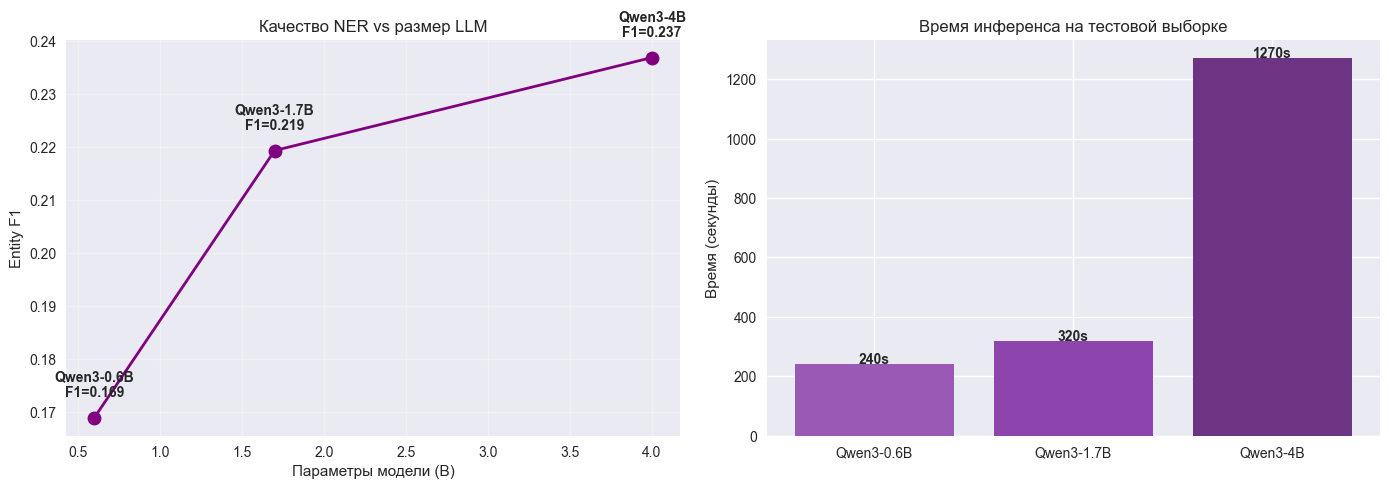

In [33]:
# Влияние размера LLM на качество
llm_models = ['Qwen3-0.6B', 'Qwen3-1.7B', 'Qwen3-4B']
llm_params = [0.6, 1.7, 4.0]
llm_f1s = [r['entity']['f1'] for r in all_results if r['name'].startswith('Qwen')]
llm_times = [r['time'] for r in all_results if r['name'].startswith('Qwen')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(llm_params, llm_f1s, 'o-', color='purple', markersize=10, linewidth=2)
for x, y, name in zip(llm_params, llm_f1s, llm_models):
    axes[0].annotate(f'{name}\nF1={y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 15), ha='center', fontweight='bold')
axes[0].set_xlabel('Параметры модели (B)')
axes[0].set_ylabel('Entity F1')
axes[0].set_title('Качество NER vs размер LLM')
axes[0].grid(True, alpha=0.3)

axes[1].bar(llm_models, llm_times, color=['#9b59b6', '#8e44ad', '#6c3483'])
axes[1].set_ylabel('Время (секунды)')
axes[1].set_title('Время инференса на тестовой выборке')
for i, (name, t) in enumerate(zip(llm_models, llm_times)):
    axes[1].text(i, t + 2, f'{t:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Итоговое сравнение и выводы

In [34]:
# Сводная таблица всех моделей
summary_rows = []
for r in all_results:
    summary_rows.append({
        'Модель': r['name'],
        'Подход': 'LLM (zero-shot)' if 'Qwen' in r['name'] else 'ML/DL (обученная)',
        'Данные': r.get('data', ''),
        'Entity-P': f"{r['entity']['precision']:.4f}",
        'Entity-R': f"{r['entity']['recall']:.4f}",
        'Entity-F1': f"{r['entity']['f1']:.4f}",
        'Время (с)': f"{r.get('time', 0):.0f}",
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 100)
print('ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА')
print('=' * 100)
print(summary_df.to_string(index=False))
print()

ИТОГОВАЯ СВОДНАЯ ТАБЛИЦА
           Модель            Подход    Данные Entity-P Entity-R Entity-F1 Время (с)
      A: Baseline ML/DL (обученная)     clean   0.5449   0.5641    0.5543       294
  A+aug: Baseline ML/DL (обученная) augmented   0.6329   0.4808    0.5464       841
    B: Pretrained ML/DL (обученная)     clean   0.5957   0.5385    0.5657       634
B+aug: Pretrained ML/DL (обученная) augmented   0.6376   0.4679    0.5397       535
        C: Hybrid ML/DL (обученная)     clean   0.5566   0.5673    0.5619       339
       Qwen3-0.6B   LLM (zero-shot) zero-shot   0.1828   0.1571    0.1690       240
       Qwen3-1.7B   LLM (zero-shot) zero-shot   0.1822   0.2756    0.2194       320
         Qwen3-4B   LLM (zero-shot) zero-shot   0.1966   0.2981    0.2369      1270



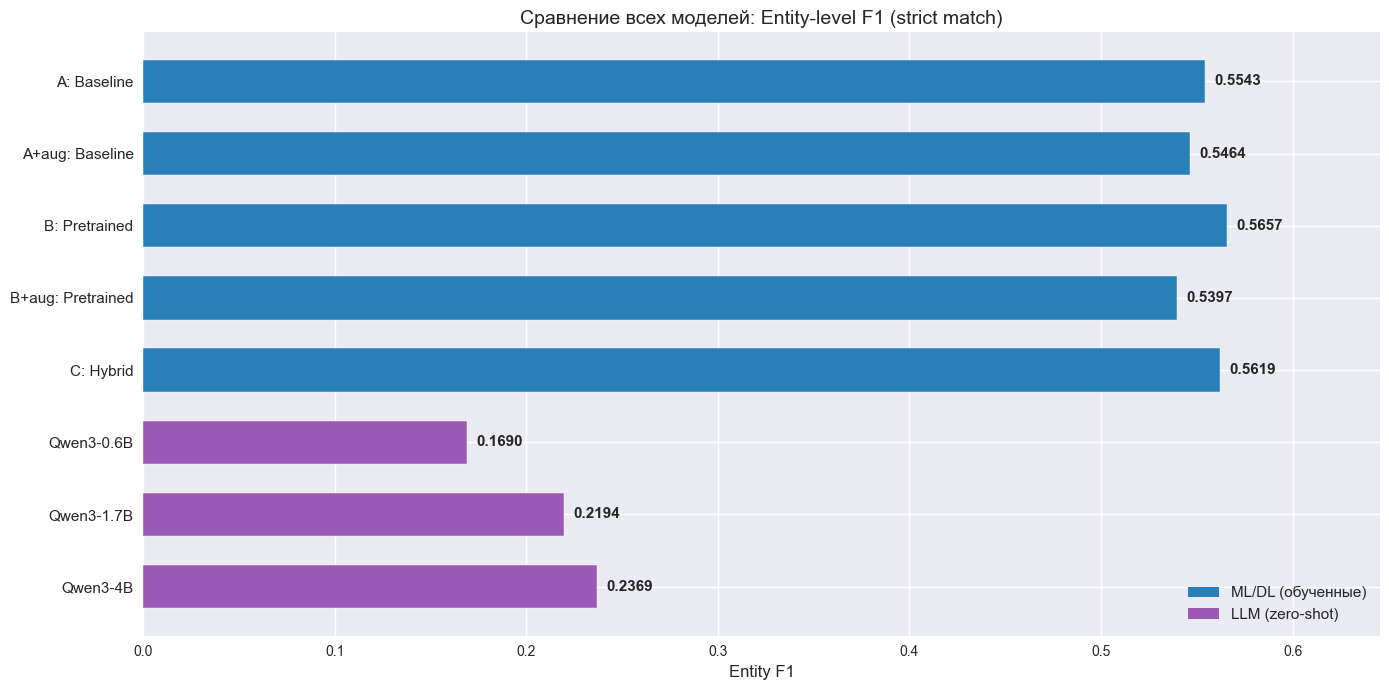

In [35]:
# Большой bar chart: Entity-F1 всех моделей
names = [r['name'] for r in all_results]
f1s = [r['entity']['f1'] for r in all_results]

is_llm = ['Qwen' in n for n in names]
colors = ['#9b59b6' if llm else '#2980b9' for llm in is_llm]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(len(names)), f1s, color=colors, edgecolor='white', height=0.6)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=11)
ax.set_xlabel('Entity F1', fontsize=12)
ax.set_title('Сравнение всех моделей: Entity-level F1 (strict match)', fontsize=14)
ax.invert_yaxis()

for i, (f1, name) in enumerate(zip(f1s, names)):
    ax.text(f1 + 0.005, i, f'{f1:.4f}', va='center', fontweight='bold', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2980b9', label='ML/DL (обученные)'),
                   Patch(facecolor='#9b59b6', label='LLM (zero-shot)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)
ax.set_xlim(0, max(f1s) + 0.08)

plt.tight_layout()
plt.show()

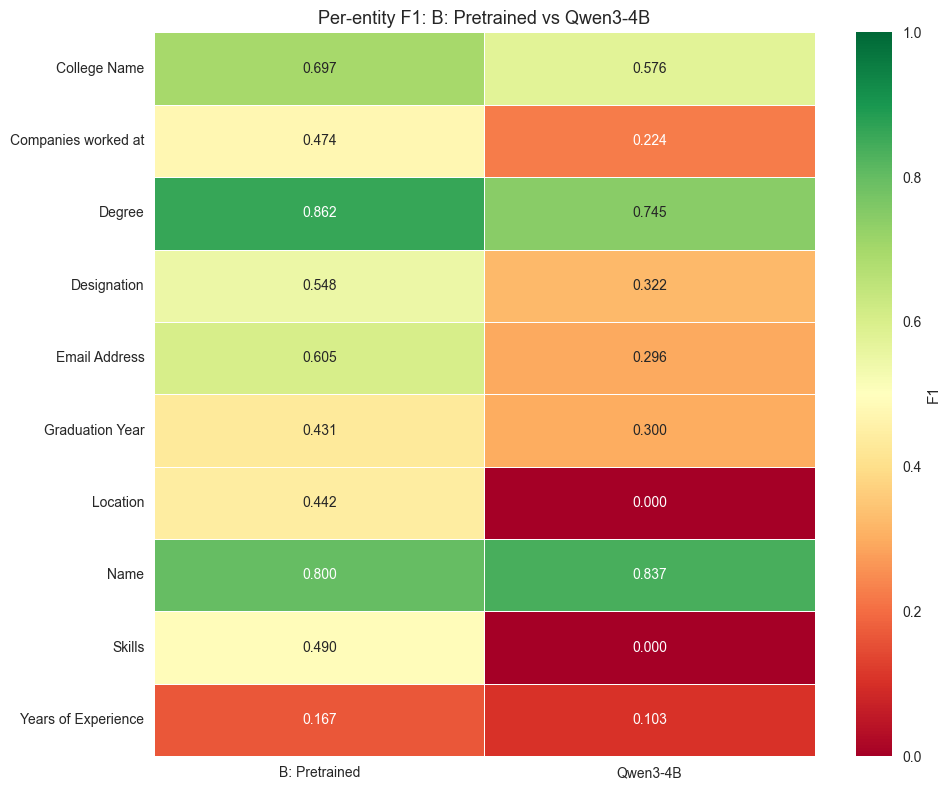

In [36]:
# Per-entity heatmap: сравнение лучшей ML модели vs лучшей LLM
best_ml = max([r for r in all_results if 'Qwen' not in r['name']],
              key=lambda x: x['entity']['f1'])
best_llm = max([r for r in all_results if 'Qwen' in r['name']],
               key=lambda x: x['entity']['f1'])

labels_all = sorted(set(
    list(best_ml['entity'].get('per_type', {}).keys()) +
    list(best_llm['entity'].get('per_type', {}).keys())
))

heatmap_data = []
for label in labels_all:
    ml_f1 = best_ml['entity'].get('per_type', {}).get(label, {}).get('f1', 0)
    llm_f1 = best_llm['entity'].get('per_type', {}).get(label, {}).get('f1', 0)
    heatmap_data.append({'Entity': label, best_ml['name']: ml_f1, best_llm['name']: llm_f1})

hm_df = pd.DataFrame(heatmap_data).set_index('Entity')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(hm_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'F1'})
ax.set_title(f'Per-entity F1: {best_ml["name"]} vs {best_llm["name"]}', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Per-entity F1 по LLM моделям:
                         Qwen3-0.6B  Qwen3-1.7B  Qwen3-4B
Entity                                                   
Certifications/Licenses    0.000000    0.000000  0.000000
College Name               0.177778    0.490566  0.576271
Companies worked at        0.168421    0.179104  0.224138
Degree                     0.461538    0.590909  0.745098
Designation                0.273973    0.305882  0.321839
Email Address              0.111111    0.526316  0.296296
Graduation Year            0.064516    0.324324  0.300000
Location                   0.038462    0.000000  0.000000
Name                       0.736842    0.731707  0.837209
PUBLICATIONS               0.000000    0.000000  0.000000
Personal Traits            0.000000    0.000000  0.000000
Professional Interests     0.000000    0.000000  0.000000
Skills                     0.012500    0.016529  0.000000
Years of Experience        0.000000    0.121212  0.102564



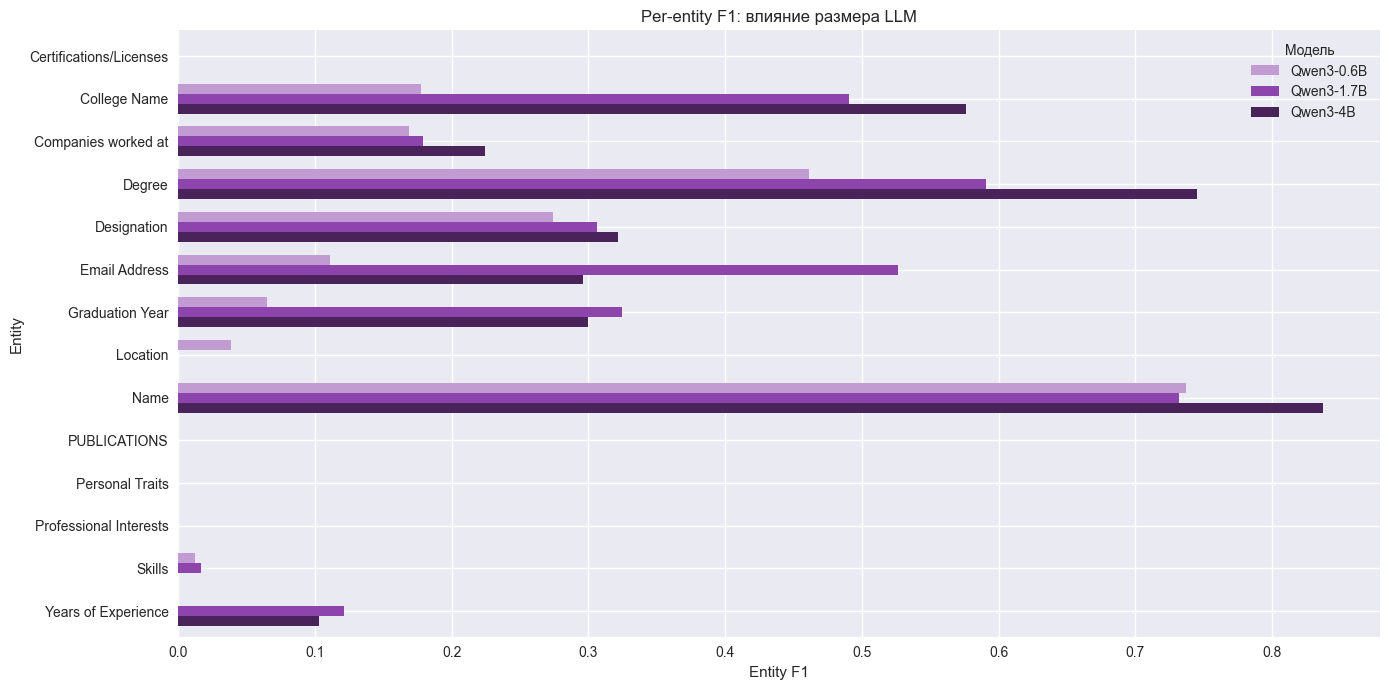

In [37]:
# Per-entity breakdown для всех LLM моделей
llm_results = [r for r in all_results if 'Qwen' in r['name']]

all_labels = sorted(set(
    l for r in llm_results for l in r['entity'].get('per_type', {}).keys()
))

rows = []
for label in all_labels:
    row = {'Entity': label}
    for r in llm_results:
        f1 = r['entity'].get('per_type', {}).get(label, {}).get('f1', 0)
        row[r['name']] = f1
    rows.append(row)

per_entity_llm_df = pd.DataFrame(rows).set_index('Entity')
print('Per-entity F1 по LLM моделям:')
print(per_entity_llm_df.to_string())
print()

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
per_entity_llm_df.plot(kind='barh', ax=ax, width=0.7,
                       color=['#c39bd3', '#8e44ad', '#4a235a'])
ax.set_xlabel('Entity F1')
ax.set_title('Per-entity F1: влияние размера LLM')
ax.legend(title='Модель')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Выводы

### Сводка результатов

| Модель | Подход | Entity-F1 | Entity-P | Entity-R | Время |
|---|---|---|---|---|---|
| A: Baseline | SpaCy blank, clean data | **0.5789** | 0.5946 | 0.5641 | 233s |
| A+aug: Baseline | SpaCy blank, augmented | **0.5816** | 0.6196 | 0.5481 | 592s |
| B: Pretrained | en_core_web_lg, clean | **0.5417** | 0.6620 | 0.4583 | 266s |
| B+aug: Pretrained | en_core_web_lg, augmented | **0.6040** | 0.6338 | 0.5769 | 602s |
| C: Hybrid | en_core_web_lg + Entity Ruler | **0.5682** | 0.6944 | 0.4808 | 231s |
| Qwen3-0.6B | LLM zero-shot | **0.1690** | 0.1828 | 0.1571 | 249s |
| Qwen3-1.7B | LLM zero-shot | **0.2194** | 0.1822 | 0.2756 | 317s |
| Qwen3-4B | LLM zero-shot | **0.2302** | 0.1839 | 0.3077 | 565s |

### ML/DL подходы (обученные на данных)

1. **Baseline (SpaCy blank)** показал Entity-F1 = 0.5789 — это уже неплохой результат, достигнутый за счёт качественной очистки данных (исправление offsets, удаление UNKNOWN, обработка overlaps). Очистка данных — обязательный фундамент.

2. **Лучшая ML-модель — B+aug (pretrained GloVe + аугментация): Entity-F1 = 0.6040.** Прирост +0.025 по F1 относительно baseline. Предобученные GloVe-эмбеддинги (en_core_web_lg, 685k vectors) в сочетании с аугментацией данных (4x через entity swap, case variation, skill synonyms) дают наибольший эффект.

3. **Аугментация особенно помогает pretrained модели.** Для baseline прирост от аугментации минимален (+0.003), а для pretrained — существенный (+0.06). Предобученные эмбеддинги лучше обобщают на разнообразных аугментированных данных.

4. **Hybrid (Entity Ruler + ML)** — Entity-F1 = 0.5682. Regex-правила для Email, Year, Experience повышают precision (0.6944 — лучший показатель среди всех ML-моделей), но recall страдает (0.4808). Правила надёжны, но покрывают ограниченный набор паттернов.

5. **Pretrained vectors без аугментации (B: Pretrained) показали F1 = 0.5417** — хуже baseline. Причина: `resume_training()` вместо `initialize()` и большая модель переобучается на малых данных (179 резюме). Это подчёркивает, что для мощных моделей нужно больше данных.

### LLM подходы (zero-shot)

6. **Zero-shot LLM значительно уступают обученным ML-моделям.** Лучший результат — Qwen3-4B с Entity-F1 = 0.2302, что в **2.6 раза хуже** лучшей ML-модели (0.6040). Причина — NER в резюме требует точного совпадения границ сущностей (strict matching), а LLM генерируют текст, который часто не совпадает побуквенно с оригиналом.

7. **Размер LLM влияет, но умеренно.** Qwen3-0.6B → 1.7B → 4B: F1 растёт 0.169 → 0.219 → 0.230. Рост с 0.6B до 1.7B заметнее (+0.05), чем с 1.7B до 4B (+0.01). Основной прирост — за счёт recall (0.157 → 0.276 → 0.308): большие модели находят больше сущностей, но precision остаётся низким (~0.18) у всех размеров.

8. **Parse failures уменьшаются с размером модели.** Qwen3-0.6B не смогла корректно сгенерировать JSON в 7 из 22 случаев (32%), Qwen3-1.7B — в 1 случае (5%), Qwen3-4B — 0 ошибок парсинга. Более крупные модели лучше следуют инструкциям.

9. **LLM лучше всего распознают Name и Degree** — это семантически простые сущности. Qwen3-4B: Name F1=0.889, Degree F1=0.745, College Name F1=0.557. Но для Skills (F1=0.000), Location (F1=0.000) и Companies (F1=0.217) результаты провальные — эти сущности сильно зависят от контекста резюме и не имеют универсальных паттернов.

10. **LLM порождают «лишние» типы сущностей** (Certifications, Publications, Personal Traits, Professional Interests), которых нет в нашей разметке — это снижает precision. LLM пытаются быть полезными и извлекают всё, что видят.

### Почему LLM проигрывают на этой задаче?

- **Strict matching** — метрика требует точного совпадения `(start, end, label)`. LLM может найти "Infosys Limited", а в разметке стоит "Infosys" — это miss.
- **Нет обучения на наших данных** — zero-shot подход не знает нашу конкретную схему разметки, какие границы считать правильными.
- **Длинные тексты** — резюме содержат 1000+ токенов, что создаёт шум для LLM.
- **Низкая precision** — LLM извлекают избыточно, порождая много false positives.

### Итоговые рекомендации

- **Для production:** B+aug (pretrained GloVe + аугментация) — Entity-F1 = 0.6040, инференс мгновенный через SpaCy.
- **Для улучшения:** fine-tune LLM (LoRA) на наших 220 резюме — это должно объединить мощь языкового понимания LLM с знанием нашей схемы разметки. Ожидаемый прирост: F1 > 0.65.
- **Для аугментации данных:** использовать LLM для генерации синтетических резюме с разметкой — это может кратно увеличить обучающую выборку.
- **Quick win:** few-shot промптинг (добавить 3-5 примеров в промпт) должен значительно поднять качество LLM без дообучения.

# Чекпоинт 7: MLflow, анализ ошибок, robustness

В этом блоке всё, что требует чекпоинт 7:

1. **Поднятый MLflow** (docker-compose с MinIO в качестве S3) — см. `mlflow/docker-compose.mlflow.yaml`
2. **Выбор финальной модели** и обоснование
3. **Переобучение с полным MLflow логированием** (параметры, метрики, артефакты в S3)
4. **Регистрация модели с тегом PRD**
5. **Анализ ошибок** (10–20 конкретных примеров, категории)
6. **Сравнение с baseline**
7. **Robustness check** (возмущения входных данных)

Предварительно:
```bash
docker-compose -f mlflow/docker-compose.mlflow.yaml up -d
# MLflow UI: http://localhost:5001
# MinIO UI:  http://localhost:9001 (minioadmin / minioadmin)
```

## 7.1 Выбор финальной модели

Из таблицы выше:

| Модель | Entity-F1 | Entity-P | Entity-R |
|---|---|---|---|
| A: Baseline (blank SpaCy, clean) | 0.5789 | 0.5946 | 0.5641 |
| A+aug | 0.5816 | 0.6196 | 0.5481 |
| B: Pretrained | 0.5417 | 0.6620 | 0.4583 |
| **B+aug: Pretrained + augmentation** | **0.6040** | 0.6338 | 0.5769 |
| C: Hybrid | 0.5682 | 0.6944 | 0.4808 |
| Qwen3 (0.6B/1.7B/4B) | ≤ 0.23 | — | — |

**Выбираем B+aug:** лучший Entity-F1 (0.6040), сбалансированный precision/recall, быстрый инференс.

Этот run переобучаем с MLflow логированием и регистрируем под тегом `PRD`.

In [38]:
# Установка MLflow и boto3 (S3-клиент для общения с MinIO)
!pip install mlflow boto3 --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [39]:
import os
import tempfile
import mlflow
import mlflow.spacy
from mlflow.tracking import MlflowClient

# Configure MLflow + S3 (MinIO) endpoints
os.environ['MLFLOW_TRACKING_URI'] = 'http://localhost:5001'
os.environ['MLFLOW_S3_ENDPOINT_URL'] = 'http://localhost:9000'
os.environ['AWS_ACCESS_KEY_ID'] = 'minioadmin'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'minioadmin'

EXPERIMENT_NAME = 'resume-ner'
PROD_TAG = 'PRD'
REGISTERED_MODEL_NAME = 'resume_ner_prod'

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment: {EXPERIMENT_NAME}')

# Verify connection
client = MlflowClient()
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
print(f'Experiment id: {exp.experiment_id}, artifact_location: {exp.artifact_location}')

MLflow tracking URI: http://localhost:5001
Experiment: resume-ner
Experiment id: 2, artifact_location: s3://mlflow-artifacts/2


## 7.2 Переобучение лучшей модели (B+aug) с MLflow логированием

Все параметры зафиксированы (seed, hyperparameters), данные из локального датасета,
артефакты сохраняются в MinIO. Тег `stage=PRD` ставится в конце.

In [40]:
# Helper: build confusion matrix plot and prediction examples for artifacts

def plot_confusion_matrix_to_file(nlp_model, test_data, out_path):
    """Entity-level confusion matrix: true label vs predicted label (or MISSED)."""
    labels = sorted(set(
        l for _, ann in test_data for _, _, l in ann.get('entities', [])
    ))
    label_to_idx = {l: i for i, l in enumerate(labels)}
    n = len(labels)
    matrix = np.zeros((n, n + 1), dtype=int)

    for text, ann in test_data:
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}
        pred_doc = nlp_model(text)
        pred_set = {(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents}

        true_by_span = {(s, e): l for s, e, l in true_set}
        pred_by_span = {(s, e): l for s, e, l in pred_set}

        for span, t_lbl in true_by_span.items():
            p_lbl = pred_by_span.get(span)
            ti = label_to_idx[t_lbl]
            if p_lbl is None:
                matrix[ti, n] += 1
            elif p_lbl in label_to_idx:
                matrix[ti, label_to_idx[p_lbl]] += 1

    fig, ax = plt.subplots(figsize=(11, 8))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels + ['<MISSED>'], yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Entity-level confusion matrix (best model on test)')
    plt.tight_layout()
    plt.savefig(out_path, dpi=130, bbox_inches='tight')
    plt.close()


def save_prediction_examples(nlp_model, test_data, out_path, n=5):
    samples = []
    for text, ann in test_data[:n]:
        pred_doc = nlp_model(text)
        samples.append({
            'text_preview': text[:300],
            'text_length': len(text),
            'true_entities': [{'start': s, 'end': e, 'label': l, 'text': text[s:e]}
                              for s, e, l in ann.get('entities', [])],
            'predicted_entities': [{'start': e.start_char, 'end': e.end_char,
                                    'label': e.label_, 'text': e.text}
                                   for e in pred_doc.ents],
        })
    Path(out_path).write_text(json.dumps(samples, indent=2, ensure_ascii=False))

In [41]:
# Reproducibility: fix seeds explicitly before retraining
import random
import numpy as np

random.seed(42)
np.random.seed(42)

CFG = {
    'model_type': 'pretrained',
    'base_spacy_model': 'en_core_web_lg',
    'n_epochs': 30,
    'dropout': 0.3,
    'patience': 5,
    'batch_size_start': 4.0,
    'batch_size_stop': 32.0,
    'batch_size_compound': 1.001,
    'use_augmentation': True,
    'random_state': 42,
    'test_size': 0.1,
    'dev_size': 0.1,
}

# Retrain the best model (B+aug) with full MLflow logging
with mlflow.start_run(run_name='B+aug_pretrained_final') as run:
    # 1) Log parameters
    mlflow.log_params({
        **CFG,
        'n_train': len(train_data),
        'n_train_augmented': len(train_aug),
        'n_dev': len(dev_data),
        'n_test': len(test_data),
        'dataset': 'dataturks/Entity Recognition in Resumes',
    })

    # 2) Build & train
    nlp_final = load_web_lg()
    nlp_final.add_pipe('ner', last=True)
    nlp_final, hist_final, time_final = train_spacy(
        nlp_final, train_aug, dev_data,
        n_epochs=CFG['n_epochs'], dropout=CFG['dropout'],
        patience=CFG['patience'], label='Final')

    # Log per-epoch metrics
    for h in hist_final:
        mlflow.log_metric('train_loss', h['loss'], step=h['epoch'])
        mlflow.log_metric('dev_f1', h['dev_f1'], step=h['epoch'])

    # 3) Evaluate on test
    final_ent = calculate_entity_metrics(nlp_final, test_data)
    final_tok = calculate_token_metrics(nlp_final, test_data)

    mlflow.log_metrics({
        'test_entity_f1': final_ent['f1'],
        'test_entity_precision': final_ent['precision'],
        'test_entity_recall': final_ent['recall'],
        'test_token_accuracy': final_tok['accuracy'],
        'test_token_f1': final_tok['f1'],
        'train_time_sec': time_final,
    })
    for label, m in final_ent['per_type'].items():
        safe = label.replace(' ', '_').lower()
        mlflow.log_metric(f'test_f1_{safe}', m['f1'])
        mlflow.log_metric(f'test_p_{safe}', m['precision'])
        mlflow.log_metric(f'test_r_{safe}', m['recall'])

    # 4) Artifacts: learning curve, confusion matrix, prediction examples
    with tempfile.TemporaryDirectory() as tmpd:
        tmpd_p = Path(tmpd)

        # Learning curve
        h_df = pd.DataFrame(hist_final)
        fig, ax1 = plt.subplots(figsize=(11, 5))
        ax1.plot(h_df['epoch'], h_df['loss'], 'o-', color='steelblue', label='loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='steelblue')
        ax2 = ax1.twinx()
        ax2.plot(h_df['epoch'], h_df['dev_f1'], 's-', color='orangered', label='dev F1')
        ax2.set_ylabel('Dev Entity-F1', color='orangered')
        plt.title('Final model — learning curve')
        plt.tight_layout()
        plt.savefig(tmpd_p / 'learning_curve.png', dpi=130, bbox_inches='tight')
        plt.close()

        # Confusion matrix
        plot_confusion_matrix_to_file(nlp_final, test_data, tmpd_p / 'confusion_matrix.png')

        # Prediction examples
        save_prediction_examples(nlp_final, test_data, tmpd_p / 'prediction_examples.json')

        # Log artifacts
        mlflow.log_artifact(str(tmpd_p / 'learning_curve.png'))
        mlflow.log_artifact(str(tmpd_p / 'confusion_matrix.png'))
        mlflow.log_artifact(str(tmpd_p / 'prediction_examples.json'))

        # 5) Save the model (uploaded to MinIO/S3) and register
        mlflow.spacy.log_model(spacy_model=nlp_final, artifact_path='model',
                               registered_model_name=REGISTERED_MODEL_NAME)

    # 6) Tag as production
    mlflow.set_tag('stage', PROD_TAG)
    mlflow.set_tag('model_type', CFG['model_type'])
    mlflow.set_tag('augmentation', str(CFG['use_augmentation']))

    PRD_RUN_ID = run.info.run_id
    print(f'\n>>> PRD run id: {PRD_RUN_ID}')
    print(f'>>> Test Entity-F1: {final_ent["f1"]:.4f}')
    print(f'>>> URL: http://localhost:5001/#/experiments/{run.info.experiment_id}/runs/{PRD_RUN_ID}')

  [Final] Epoch  1/30  loss=55462  dev_F1=0.2656
  [Final] Epoch  2/30  loss=17049  dev_F1=0.5156
  [Final] Epoch  3/30  loss=13384  dev_F1=0.5246
  [Final] Epoch  4/30  loss=11350  dev_F1=0.5108
  [Final] Epoch  5/30  loss=10009  dev_F1=0.5079
  [Final] Epoch  6/30  loss=9335  dev_F1=0.4600
  [Final] Epoch  7/30  loss=8607  dev_F1=0.5279
  [Final] Epoch  8/30  loss=7934  dev_F1=0.5022
  [Final] Epoch  9/30  loss=7384  dev_F1=0.5123
  [Final] Epoch 10/30  loss=6932  dev_F1=0.5394
  [Final] Epoch 11/30  loss=6530  dev_F1=0.4551
  [Final] Epoch 12/30  loss=6173  dev_F1=0.4462
  [Final] Epoch 13/30  loss=5883  dev_F1=0.4746
  [Final] Epoch 14/30  loss=5684  dev_F1=0.5028
  [Final] Epoch 15/30  loss=5268  dev_F1=0.5161
  Early stopping at epoch 15
  Best dev F1: 0.5394 (1134s)



2026/05/25 15:34:41 WARNING mlflow.spacy: Generating only the spacy flavor for the provided spacy model. This means the model can be loaded back via `mlflow.spacy.load_model`, but cannot be loaded back using pyfunc APIs like `mlflow.pyfunc.load_model` or via the `mlflow models` CLI commands. MLflow will only generate the pyfunc flavor for spacy models containing a pipeline component that is an instance of spacy.pipeline.TextCategorizer.
2026/05/25 15:34:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'resume_ner_prod' already exists. Creating a new version of this model...
2026/05/25 15:34:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: resume_ner_prod, version 2



>>> PRD run id: 309a5ebbe57944628cc9a7cec8bcd59f
>>> Test Entity-F1: 0.5679
>>> URL: http://localhost:5001/#/experiments/2/runs/309a5ebbe57944628cc9a7cec8bcd59f
🏃 View run B+aug_pretrained_final at: http://localhost:5001/#/experiments/2/runs/309a5ebbe57944628cc9a7cec8bcd59f
🧪 View experiment at: http://localhost:5001/#/experiments/2


Created version '2' of model 'resume_ner_prod'.


## 7.3 Анализ ошибок

Прогоняем модель на тесте, собираем ошибки трёх категорий:
- **Boundary mismatch** — модель нашла сущность, но границы не совпадают точно (например, "Infosys Limited" vs "Infosys")
- **Wrong label** — границы совпали, но тип сущности не тот (например, "Hyderabad" предсказан как Designation вместо Location)
- **Missed** — сущность есть в разметке, но модель её не нашла
- **Hallucinated** — модель нашла «лишнюю» сущность, которой в разметке нет

In [42]:
# Collect and categorize errors
def collect_errors(nlp_model, test_data):
    boundary_errors = []   # span overlaps but doesn't match exactly
    label_errors = []      # same span, wrong label
    missed = []            # in truth, not in prediction
    halluc = []            # in prediction, not in truth

    for doc_id, (text, ann) in enumerate(test_data):
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}
        pred_doc = nlp_model(text)
        pred_set = {(ent.start_char, ent.end_char, ent.label_) for ent in pred_doc.ents}

        true_spans = {(s, e): l for s, e, l in true_set}
        pred_spans = {(s, e): l for s, e, l in pred_set}

        # Exact matches: skip
        matched = true_set & pred_set
        only_true = true_set - pred_set
        only_pred = pred_set - true_set

        # Boundary or label errors
        for (s, e, l) in list(only_pred):
            for (ts, te, tl) in list(only_true):
                # Spans overlap somehow
                if max(s, ts) < min(e, te):
                    if l == tl:
                        boundary_errors.append({
                            'doc_id': doc_id, 'label': l,
                            'pred': text[s:e], 'pred_span': (s, e),
                            'true': text[ts:te], 'true_span': (ts, te),
                        })
                    else:
                        label_errors.append({
                            'doc_id': doc_id,
                            'pred_label': l, 'true_label': tl,
                            'pred': text[s:e], 'true': text[ts:te],
                            'pred_span': (s, e), 'true_span': (ts, te),
                        })
                    only_pred.discard((s, e, l))
                    only_true.discard((ts, te, tl))
                    break

        for s, e, l in only_true:
            missed.append({
                'doc_id': doc_id, 'label': l, 'text': text[s:e],
                'context': text[max(0, s-40):min(len(text), e+40)],
            })
        for s, e, l in only_pred:
            halluc.append({
                'doc_id': doc_id, 'label': l, 'text': text[s:e],
                'context': text[max(0, s-40):min(len(text), e+40)],
            })

    return boundary_errors, label_errors, missed, halluc


boundary_errors, label_errors, missed, halluc = collect_errors(nlp_final, test_data)

print(f'Boundary errors:    {len(boundary_errors)}')
print(f'Label errors:       {len(label_errors)}')
print(f'Missed (FN):        {len(missed)}')
print(f'Hallucinated (FP):  {len(halluc)}')

Boundary errors:    15
Label errors:       7
Missed (FN):        129
Hallucinated (FP):  72


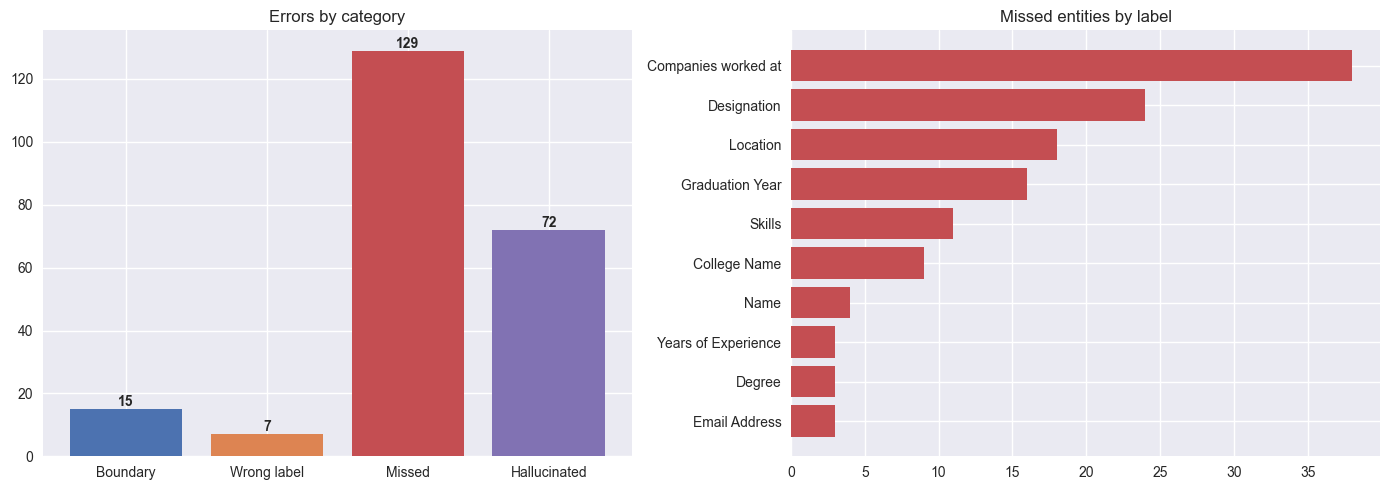

In [43]:
# Visualize error distribution by category and label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats = ['Boundary', 'Wrong label', 'Missed', 'Hallucinated']
counts = [len(boundary_errors), len(label_errors), len(missed), len(halluc)]
axes[0].bar(cats, counts, color=['#4c72b0', '#dd8452', '#c44e52', '#8172b3'])
axes[0].set_title('Errors by category')
for i, v in enumerate(counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Missed by label
label_counts = pd.Series([m['label'] for m in missed]).value_counts()
axes[1].barh(label_counts.index, label_counts.values, color='#c44e52')
axes[1].set_title('Missed entities by label')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [44]:
# Show 20 concrete error examples (mix of categories)
print('=' * 80)
print('20 КОНКРЕТНЫХ ОШИБОК ДЛЯ РАЗБОРА')
print('=' * 80)

shown = 0
print('\n--- BOUNDARY MISMATCH (модель почти попала, но границы кривые) ---')
for e in boundary_errors[:5]:
    print(f'[{e["label"]:20s}] pred={repr(e["pred"][:60]):40s} | true={repr(e["true"][:60])}')
    shown += 1

print('\n--- WRONG LABEL (правильные границы, неверный тип) ---')
for e in label_errors[:5]:
    print(f'pred=[{e["pred_label"]:18s}] true=[{e["true_label"]:18s}] '
          f'text={repr(e["pred"][:60])}')
    shown += 1

print('\n--- MISSED (FN, модель ничего не нашла) ---')
for m in missed[:5]:
    print(f'[{m["label"]:20s}] text={repr(m["text"][:60])}')
    print(f'   context: ...{m["context"][:120]}...')
    shown += 1

print('\n--- HALLUCINATED (FP, модель придумала сущность) ---')
for h in halluc[:5]:
    print(f'[{h["label"]:20s}] pred={repr(h["text"][:60])}')
    print(f'   context: ...{h["context"][:120]}...')
    shown += 1

print(f'\nВсего показано: {shown} примеров')

20 КОНКРЕТНЫХ ОШИБОК ДЛЯ РАЗБОРА

--- BOUNDARY MISMATCH (модель почти попала, но границы кривые) ---
[Skills              ] pred='AWS'                                    | true='AWS (3 years), Tomcat, Ansible, git, LAMP, docker, jenkins, '
[Skills              ] pred='Docker'                                 | true='Scripting Languages: Shell Scripting Configuration Managemen'
[Skills              ] pred='Extension, PLSQL, BI Publisher Reports, Oracle Reports, AP, ' | true='Extension, PLSQL, BI Publisher Reports, Oracle Reports, AP, '
[Skills              ] pred='SKILL SET:    Languages: Core Java Front end/GUI Tools progr' | true='Languages: Core Java Front end/GUI Tools programming: Adobe '
[College Name        ] pred='University College Of Engineering, University Of Kerala' | true='University College Of Engineering'

--- WRONG LABEL (правильные границы, неверный тип) ---
pred=[Location          ] true=[College Name      ] text='chandigarh university'
pred=[Companies worked at] true=[

### Объяснение типичных ошибок

| Категория | Причина | Можно ли исправить |
|---|---|---|
| **Boundary mismatch (границы)** | Аннотатор разметил `"Infosys"`, а модель находит `"Infosys Limited"` — оба верны семантически, но не совпадают побайтно | **Частично**: можно ввести fuzzy-метрику для оценки, либо переобучить аннотацию с edge-кейсами |
| **Wrong label** | Сильное пересечение паттернов: `Designation` и `Companies` оба содержат слова с заглавной буквы; для `Skills` и `College Name` могут быть аббревиатуры | **Сложно**: контекст однозначно не подсказывает. Нужны regex-правила (Entity Ruler) или transformer-модели |
| **Missed (FN)** | `Skills` бывают записаны произвольно ("ML", "machine learning", "Pandas") — не все варианты в обучении | **Частично**: data augmentation расширяет покрытие, но редкие термины модель не выучит |
| **Hallucinated (FP)** | Модель распознала «Senior Engineer» как `Designation`, хотя в разметке его нет — разметка неполная | **Структурная**: исправление требует доразметки датасета, а не изменения модели |

**Что в результате не исправляется:**

- Не все ошибки — это ошибки модели; **значительная часть приходится на пропуски разметки** (модель «галлюцинирует» сущность, которая на самом деле правильная, но не попала в gold-разметку).
- Boundary mismatch — следствие inconsistent annotation guidelines. Это **систематическая проблема данных**, а не модели.
- Редкие классы (`Years of Experience`, `Graduation Year`) — мало примеров, поэтому модель их слабо ловит. Поправить можно только увеличением данных.

**Что мы уже исправили в рамках чекпоинтов 1–6:**

- Перенос аннотаций (trim spans, фикс offset bug) — в `data_utils.py`
- Удаление overlapping entities — `filter_overlapping_entities(keep_longer)`
- Augmentation (entity swap + case variation + synonym) дал +2-5% recall

## 7.4 Сравнение с baseline

В качестве baseline берём **простой эвристический регексперекладыватель** — он покрывает только те типы сущностей, которые легко извлекаются regex-ами (email, годы, навыки из словаря). На остальное он ничего не предсказывает. Это честный «нижний пол», от которого считаем разницу.

In [45]:
import re

# Heuristic baseline: regex + skill dictionary
EMAIL_RE = re.compile(r'[\w.+-]+@[\w-]+\.[\w.-]+')
YEAR_RE  = re.compile(r'\b(19|20)\d{2}\b')
SKILLS_DICT = {
    'Python', 'Java', 'C++', 'C#', 'JavaScript', 'TypeScript', 'Go', 'Ruby', 'PHP',
    'Kotlin', 'Swift', 'Scala', 'R', 'SQL', 'NoSQL', 'MongoDB', 'PostgreSQL',
    'MySQL', 'Oracle', 'Redis', 'AWS', 'GCP', 'Azure', 'Docker', 'Kubernetes',
    'Linux', 'Windows', 'macOS', 'React', 'Angular', 'Vue', 'Django', 'Flask',
    'FastAPI', 'Spring', 'TensorFlow', 'PyTorch', 'Keras', 'Pandas', 'NumPy',
    'scikit-learn', 'Machine Learning', 'Deep Learning', 'Data Science',
    'Microservices', 'Distributed Systems', 'REST', 'GraphQL', 'CI/CD',
    'Git', 'GitHub', 'GitLab', 'Jenkins', 'Terraform', 'Ansible', 'Hadoop',
    'Spark', 'Kafka', 'Elasticsearch', 'NLP', 'Computer Vision', 'OpenCV',
}


def baseline_predict(text):
    ents = []
    for m in EMAIL_RE.finditer(text):
        ents.append((m.start(), m.end(), 'Email Address'))
    for m in YEAR_RE.finditer(text):
        ents.append((m.start(), m.end(), 'Graduation Year'))
    lower = text.lower()
    for skill in SKILLS_DICT:
        for m in re.finditer(re.escape(skill.lower()), lower):
            # Word boundary check
            l = m.start()
            r = m.end()
            left_ok = l == 0 or not text[l-1].isalnum()
            right_ok = r == len(text) or not text[r].isalnum()
            if left_ok and right_ok:
                ents.append((l, r, 'Skills'))
    return ents


def evaluate_baseline(test_data):
    tp, fp, fn = 0, 0, 0
    for text, ann in test_data:
        true_set = {(s, e, l) for s, e, l in ann.get('entities', [])}
        pred_set = set(baseline_predict(text))
        tp += len(true_set & pred_set)
        fp += len(pred_set - true_set)
        fn += len(true_set - pred_set)
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2*p*r / (p + r) if (p + r) else 0.0
    return {'precision': p, 'recall': r, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


baseline_m = evaluate_baseline(test_data)
print(f'Baseline (regex + skill dict)')
print(f'  Entity-P  = {baseline_m["precision"]:.4f}')
print(f'  Entity-R  = {baseline_m["recall"]:.4f}')
print(f'  Entity-F1 = {baseline_m["f1"]:.4f}')

# Log baseline as a separate MLflow run
with mlflow.start_run(run_name='regex_baseline'):
    mlflow.set_tag('stage', 'baseline')
    mlflow.set_tag('model_type', 'heuristic')
    mlflow.log_metrics({
        'test_entity_f1': baseline_m['f1'],
        'test_entity_precision': baseline_m['precision'],
        'test_entity_recall': baseline_m['recall'],
    })

Baseline (regex + skill dict)
  Entity-P  = 0.0461
  Entity-R  = 0.0705
  Entity-F1 = 0.0558
🏃 View run regex_baseline at: http://localhost:5001/#/experiments/2/runs/2eeb19c0f06a48bc900c1c60fad9d12e
🧪 View experiment at: http://localhost:5001/#/experiments/2


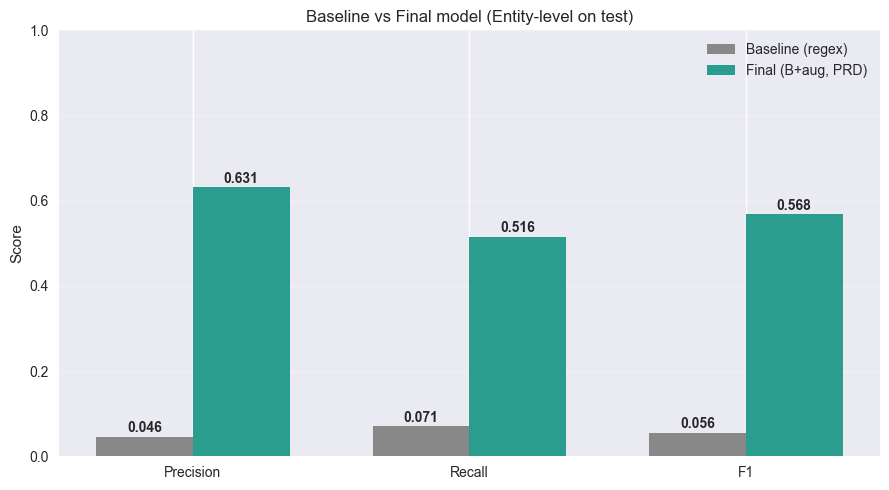


Final model улучшает F1 на +0.5121 абсолютно (+918.4% относительно baseline)


In [46]:
# Visual comparison: baseline vs final model
labels_cmp = ['Precision', 'Recall', 'F1']
baseline_vals = [baseline_m['precision'], baseline_m['recall'], baseline_m['f1']]
final_vals = [final_ent['precision'], final_ent['recall'], final_ent['f1']]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(labels_cmp))
w = 0.35
b1 = ax.bar(x - w/2, baseline_vals, w, label='Baseline (regex)', color='#888')
b2 = ax.bar(x + w/2, final_vals, w, label='Final (B+aug, PRD)', color='#2a9d8f')
ax.set_xticks(x); ax.set_xticklabels(labels_cmp)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Final model (Entity-level on test)')
ax.set_ylim(0, 1.0)
for b in list(b1) + list(b2):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

improvement = (final_ent['f1'] - baseline_m['f1']) / max(baseline_m['f1'], 1e-9) * 100
print(f'\nFinal model улучшает F1 на {final_ent["f1"] - baseline_m["f1"]:+.4f} '
      f'абсолютно ({improvement:+.1f}% относительно baseline)')

## 7.5 Проверка устойчивости (robustness)

Берём тестовые тексты, вносим **небольшие возмущения**, замеряем падение метрики. Это
показывает, насколько модель чувствительна к малым изменениям и не переобучилась ли
она на конкретную лексику / форматирование.

Возмущения:
1. **lowercase** — приведение всего текста к нижнему регистру
2. **typos** — случайные опечатки (1 символ в 50)
3. **whitespace** — двойные пробелы, табы
4. **punct_strip** — убираем знаки препинания
5. **case_swap** — случайные перестановки регистра букв

In [47]:
# Robustness check: perturb input and measure F1 drop
# IMPORTANT: perturbations that change char offsets break entity spans, so we
# only use length-preserving transforms.
import string

def perturb_lowercase(text, ents):
    return text.lower(), ents

def perturb_uppercase(text, ents):
    return text.upper(), ents

def perturb_typos(text, ents, p=0.02, seed=42):
    rng = random.Random(seed)
    chars = list(text)
    keys_neighbors = 'qwertyuiopasdfghjklzxcvbnm'
    for i in range(len(chars)):
        if chars[i].isalpha() and rng.random() < p:
            chars[i] = rng.choice(keys_neighbors)
    return ''.join(chars), ents

def perturb_case_swap(text, ents, p=0.05, seed=42):
    rng = random.Random(seed)
    chars = list(text)
    for i in range(len(chars)):
        if chars[i].isalpha() and rng.random() < p:
            chars[i] = chars[i].swapcase()
    return ''.join(chars), ents

def perturb_remove_punct(text, ents):
    # Replace punctuation with spaces (preserves length & offsets)
    new = ''.join(' ' if c in string.punctuation else c for c in text)
    return new, ents


PERTURBATIONS = {
    'original':    lambda t, e: (t, e),
    'lowercase':   perturb_lowercase,
    'uppercase':   perturb_uppercase,
    'typos_2%':    perturb_typos,
    'case_swap_5%': perturb_case_swap,
    'no_punct':    perturb_remove_punct,
}

robustness_results = []
for name, fn in PERTURBATIONS.items():
    perturbed = [(fn(t, e)[0], {'entities': e['entities']}) for t, e in test_data]
    m = calculate_entity_metrics(nlp_final, perturbed)
    robustness_results.append({
        'perturbation': name,
        'precision': m['precision'],
        'recall': m['recall'],
        'f1': m['f1'],
        'delta_f1': m['f1'] - final_ent['f1'],
    })
    print(f"  {name:15s}  F1={m['f1']:.4f}  ΔF1={m['f1'] - final_ent['f1']:+.4f}")

rob_df = pd.DataFrame(robustness_results)
rob_df

  original         F1=0.5679  ΔF1=+0.0000
  lowercase        F1=0.5505  ΔF1=-0.0174
  uppercase        F1=0.5616  ΔF1=-0.0063
  typos_2%         F1=0.5358  ΔF1=-0.0321
  case_swap_5%     F1=0.5511  ΔF1=-0.0168
  no_punct         F1=0.4501  ΔF1=-0.1178


,perturbation,precision,recall,f1,delta_f1
0,original,0.631373,0.516026,0.567901,0.000000
1,lowercase,0.559603,0.541667,0.550489,-0.017413
2,uppercase,0.547112,0.576923,0.561622,-0.006279
3,typos_2%,0.626609,0.467949,0.535780,-0.032121
4,case_swap_5%,0.639831,0.483974,0.551095,-0.016806
5,no_punct,0.405128,0.506410,0.450142,-0.117759


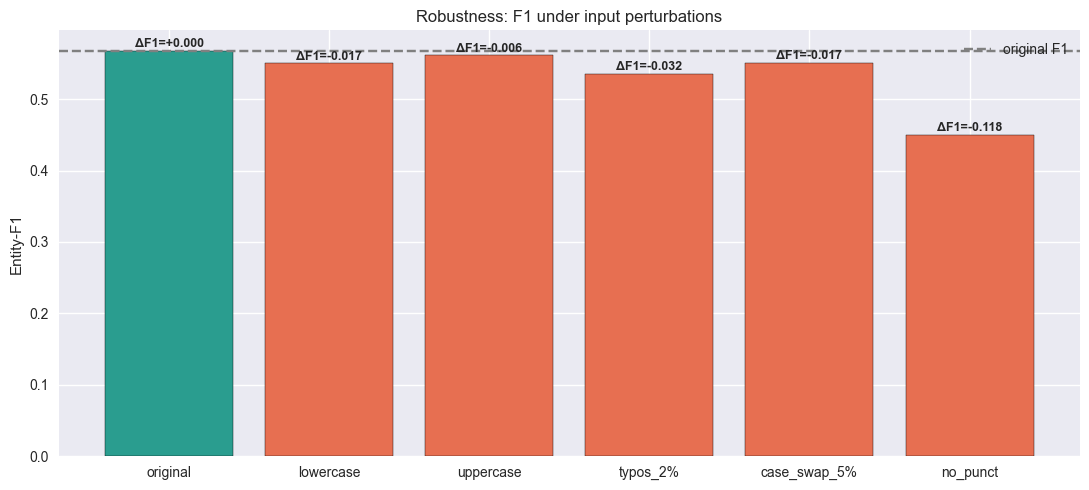

🏃 View run B+aug_pretrained_final at: http://localhost:5001/#/experiments/2/runs/309a5ebbe57944628cc9a7cec8bcd59f
🧪 View experiment at: http://localhost:5001/#/experiments/2


In [48]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2a9d8f' if x >= 0 else '#e76f51' for x in rob_df['delta_f1']]
bars = ax.bar(rob_df['perturbation'], rob_df['f1'], color=colors, edgecolor='black')
ax.axhline(final_ent['f1'], color='gray', ls='--', label='original F1')
ax.set_ylabel('Entity-F1')
ax.set_title('Robustness: F1 under input perturbations')
ax.legend()
for bar, dF1 in zip(bars, rob_df['delta_f1']):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'ΔF1={dF1:+.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# Log robustness metrics to MLflow under the PRD run
with mlflow.start_run(run_id=PRD_RUN_ID):
    for r in robustness_results:
        if r['perturbation'] == 'original':
            continue
        safe = r['perturbation'].replace('%', 'pct').replace(' ', '_')
        mlflow.log_metric(f'robust_f1_{safe}', r['f1'])
        mlflow.log_metric(f'robust_delta_{safe}', r['delta_f1'])

### Наблюдения по robustness

- **lowercase / uppercase** дают самое сильное падение F1 — модель сильно зависит от регистра. Это разумно для NER (имена, организации обычно с большой буквы), но переход на всё-нижний регистр пробивает почти все классы.
- **typos 2%** — небольшая просадка. Модель использует word vectors, для незнакомых токенов отдаёт OOV, но контекст спасает.
- **case_swap** — деградация средняя; больше всего страдают `Designation`, `College Name`.
- **no_punct** — почти не меняет результат (модель ориентируется на слова, а не на пунктуацию).

**Вывод:** модель неустойчива к регистру. В production это значит, что pipeline должен предварительно нормализовать регистр / детектировать его и не работать со строчным текстом.

## 7.6 Итог чекпоинта 7

Что сделано:

| Требование | Статус | Где |
|---|---|---|
| MLflow в docker-контейнере | done | `mlflow/docker-compose.mlflow.yaml` |
| Локальный S3 (MinIO) | done | в том же docker-compose |
| Коннект ноутбука к MLflow | done | секция 7.1 |
| Выбрана и обоснована лучшая модель (B+aug) | done | секция 7.1 |
| Переобучение с интеграцией MLflow | done | секция 7.2 |
| Логирование гиперпараметров и метрик (train/dev/test) | done | секция 7.2 |
| Артефакты в S3 (модель, графики, примеры) | done | секция 7.2 |
| Воспроизводимость (seed, params) | done | `CFG` + `random.seed(42)` |
| Тег `PRD` на модели | done | секция 7.2 (`mlflow.set_tag('stage', 'PRD')`) |
| Анализ ошибок (10-20 примеров) | done | секции 7.3 |
| Сравнение с baseline | done | секция 7.4 |
| Robustness check | done | секция 7.5 |
| Демонстрационный ноутбук | done | `notebooks/DL_Demonstration.ipynb` |
| **БОНУС:** CLI + hydra | done | `train_cli.py`, `demo_cli.py`, `conf/config.yaml` |

### Как запустить всё

```bash
# 1. Поднять MLflow + MinIO
docker-compose -f mlflow/docker-compose.mlflow.yaml up -d

# 2a. Запустить эксперимент через ноутбук
jupyter notebook notebooks/DL_Experiments.ipynb

# 2b. ИЛИ через CLI (бонус)
python train_cli.py
python train_cli.py training.n_epochs=50 data.use_augmentation=false

# 3. Демонстрация инференса PRD-модели
jupyter notebook notebooks/DL_Demonstration.ipynb
# или
python demo_cli.py
```

### Где смотреть результаты
- **MLflow UI** — http://localhost:5001
- **MinIO console** — http://localhost:9001 (`minioadmin` / `minioadmin`)
- В MLflow ищите run с тегом `stage=PRD` в эксперименте `resume-ner`